In [1]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("techmarket.db")

In [3]:
import numpy as np
from pathlib import Path
from IPython.display import display

DATA_PATH = Path("../06_Datasets/raw")

dataset_files = {
    "customers": "olist_customers_dataset.csv",
    "orders": "olist_orders_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "order_payments": "olist_order_payments_dataset.csv",
    "order_reviews": "olist_order_reviews_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "geolocation": "olist_geolocation_dataset.csv",
    "categories": "product_category_name_translation.csv"
}

datasets = {}
for name, filename in dataset_files.items():
    datasets[name] = pd.read_csv(DATA_PATH / filename)

In [4]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

datasets["orders"][date_columns] = (
    datasets["orders"][date_columns]
    .apply(pd.to_datetime)
)

In [5]:
for name, df in datasets.items():
    df.to_sql(
        name,
        conn,
        if_exists="replace",
        index=False
    )

print("Database created successfully!")

Database created successfully!


In [6]:
pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type='table';
""", conn)

,name
0,customers
1,orders
2,order_items
3,order_payments
4,order_reviews
5,products
6,sellers
7,geolocation
8,categories


# Business Question 1

## What is the size of the marketplace database?

Before starting the analysis, it is important to understand the scale of the marketplace by identifying the number of orders, customers, sellers and products stored in the database.

In [7]:
query = """
SELECT
    'Orders' AS metric,
    COUNT(*) AS total
FROM orders

UNION ALL

SELECT
    'Customers',
    COUNT(*)
FROM customers

UNION ALL

SELECT
    'Sellers',
    COUNT(*)
FROM sellers

UNION ALL

SELECT
    'Products',
    COUNT(*)
FROM products;
"""

In [8]:
marketplace_size = pd.read_sql(query, conn)

display(marketplace_size)

,metric,total
0,Orders,99441
1,Customers,99441
2,Sellers,3095
3,Products,32951


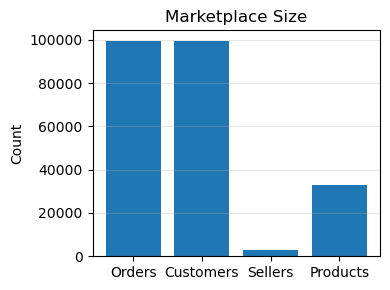

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4,3))

plt.bar(
    marketplace_size["metric"],
    marketplace_size["total"]
)

plt.title("Marketplace Size")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Business Interpretation

The marketplace contains approximately 99 thousand orders placed by nearly the same number of customers.

More than 3 thousand sellers offer around 33 thousand products, indicating a large multi-vendor marketplace with a broad assortment and significant transaction volume.

In [10]:
query = """
SELECT
    order_status,
    COUNT(*) AS orders,
    ROUND(
        COUNT(*) * 100.0 /
        (SELECT COUNT(*) FROM orders),
        2
    ) AS share_percent
FROM orders
GROUP BY order_status
ORDER BY orders DESC;
"""

order_status = pd.read_sql(query, conn)
display(order_status)

,order_status,orders,share_percent
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


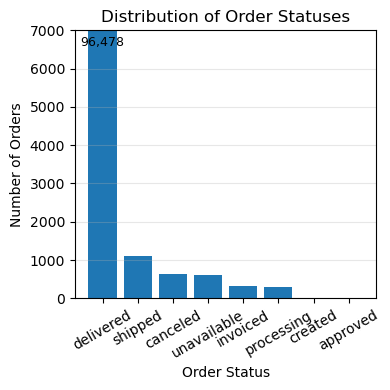

In [17]:
plt.figure(figsize=(4,4))

bars = plt.bar(order_status["order_status"], order_status["orders"])

plt.title("Distribution of Order Statuses")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)
plt.ylim(0, 7000)
plt.grid(axis="y", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    if height > 7000:
        plt.text(bar.get_x() + bar.get_width()/2., 6500,
                 f'{int(height):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [18]:
completed_share = order_status.loc[
    order_status["order_status"] == "delivered",
    "share_percent"
].iloc[0]

cancelled_share = order_status.loc[
    order_status["order_status"] == "canceled",
    "share_percent"
].iloc[0]

kpi_status = pd.DataFrame({
    "Metric": [
        "Delivered Orders",
        "Cancelled Orders"
    ],
    "Value": [
        f"{completed_share}%",
        f"{cancelled_share}%"
    ]
})

display(kpi_status)

,Metric,Value
0,Delivered Orders,97.02%
1,Cancelled Orders,0.63%


### Business Interpretation

The overwhelming majority of orders were successfully delivered, indicating a stable and reliable fulfillment process.

Only a small proportion of orders were canceled or remained in intermediate statuses, suggesting that operational disruptions are relatively rare.

Overall, the marketplace demonstrates a high order completion rate, which is a positive indicator of business performance and customer service quality.

In [21]:
query = """
SELECT
    strftime('%Y-%m', order_purchase_timestamp) AS purchase_month,
    COUNT(*) AS orders,
    COUNT(*) -
    LAG(COUNT(*))
        OVER(
            ORDER BY strftime('%Y-%m', order_purchase_timestamp)
        ) AS order_change
FROM orders
GROUP BY purchase_month
ORDER BY purchase_month;
"""

monthly_orders_sql = pd.read_sql(query, conn)
display(monthly_orders_sql)

,purchase_month,orders,order_change
0,2016-09,4,NaN
1,2016-10,324,320.0
2,2016-12,1,-323.0
3,2017-01,800,799.0
4,2017-02,1780,980.0
5,2017-03,2682,902.0
6,2017-04,2404,-278.0
7,2017-05,3700,1296.0
8,2017-06,3245,-455.0
9,2017-07,4026,781.0


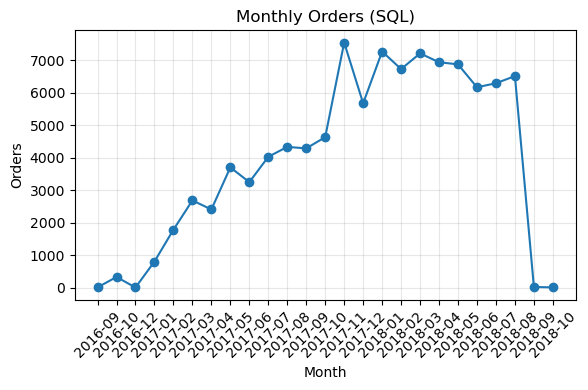

In [22]:
plt.figure(figsize=(6,4))

plt.plot(
    monthly_orders_sql["purchase_month"],
    monthly_orders_sql["orders"],
    marker="o"
)

plt.title("Monthly Orders (SQL)")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Business Interpretation

Monthly order volume increased significantly throughout 2017, indicating rapid marketplace growth.

Using the `LAG()` window function allows us to measure month-over-month changes directly in SQL without additional processing in Python.

This approach is efficient and commonly used for trend analysis in analytical databases.

In [23]:
query = """
SELECT
    strftime('%Y-%m', order_purchase_timestamp) AS purchase_month,
    COUNT(*) AS orders,
    COUNT(*) -
    LAG(COUNT(*))
        OVER(
            ORDER BY strftime('%Y-%m', order_purchase_timestamp)
        ) AS order_change
FROM orders
WHERE order_purchase_timestamp < '2018-09-01'
GROUP BY purchase_month
ORDER BY purchase_month;
"""

monthly_orders_sql = pd.read_sql(query, conn)
display(monthly_orders_sql)

,purchase_month,orders,order_change
0,2016-09,4,NaN
1,2016-10,324,320.0
2,2016-12,1,-323.0
3,2017-01,800,799.0
4,2017-02,1780,980.0
5,2017-03,2682,902.0
6,2017-04,2404,-278.0
7,2017-05,3700,1296.0
8,2017-06,3245,-455.0
9,2017-07,4026,781.0


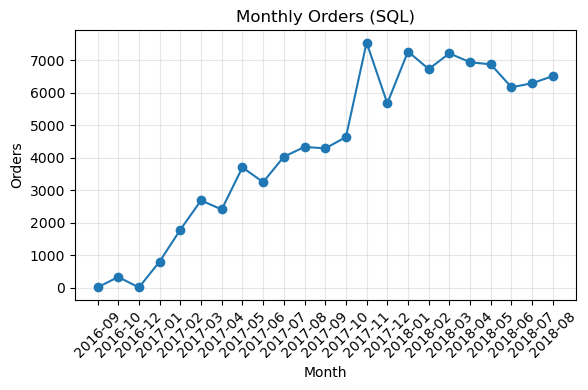

In [24]:
plt.figure(figsize=(6,4))

plt.plot(
    monthly_orders_sql["purchase_month"],
    monthly_orders_sql["orders"],
    marker="o"
)

plt.title("Monthly Orders (SQL)")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
query = """
SELECT
    strftime('%Y-%m', o.order_purchase_timestamp) AS purchase_month,
    ROUND(SUM(oi.price),2) AS revenue
FROM orders o
INNER JOIN order_items oi
ON o.order_id = oi.order_id
WHERE o.order_purchase_timestamp < '2018-09-01'
GROUP BY purchase_month
ORDER BY purchase_month;
"""

monthly_revenue = pd.read_sql(query, conn)
display(monthly_revenue)

,purchase_month,revenue
0,2016-09,267.36
1,2016-10,49507.66
2,2016-12,10.90
3,2017-01,120312.87
4,2017-02,247303.02
5,2017-03,374344.30
6,2017-04,359927.23
7,2017-05,506071.14
8,2017-06,433038.60
9,2017-07,498031.48


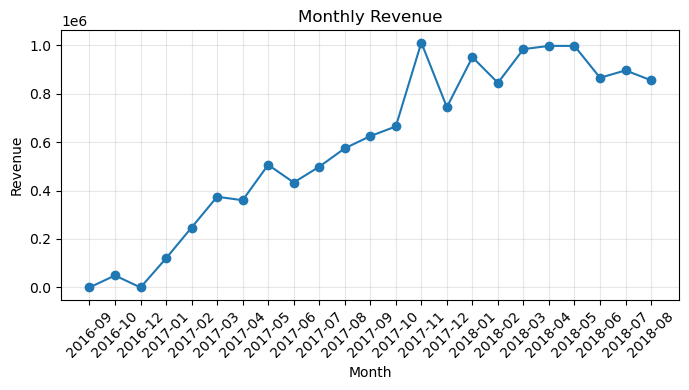

In [26]:
plt.figure(figsize=(7,4))

plt.plot(
    monthly_revenue["purchase_month"],
    monthly_revenue["revenue"],
    marker="o"
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
query = """
SELECT
    strftime('%Y-%m', o.order_purchase_timestamp) AS purchase_month,
    ROUND(SUM(oi.price),2) AS revenue,
    ROUND(
        SUM(oi.price) -
        LAG(SUM(oi.price))
        OVER(
            ORDER BY strftime('%Y-%m', o.order_purchase_timestamp)
        ),
        2
    ) AS revenue_change
FROM orders o
INNER JOIN order_items oi
ON o.order_id = oi.order_id
WHERE o.order_purchase_timestamp < '2018-09-01'
GROUP BY purchase_month
ORDER BY purchase_month;
"""

monthly_revenue = pd.read_sql(query, conn)
display(monthly_revenue)

,purchase_month,revenue,revenue_change
0,2016-09,267.36,NaN
1,2016-10,49507.66,49240.30
2,2016-12,10.90,-49496.76
3,2017-01,120312.87,120301.97
4,2017-02,247303.02,126990.15
5,2017-03,374344.30,127041.28
6,2017-04,359927.23,-14417.07
7,2017-05,506071.14,146143.91
8,2017-06,433038.60,-73032.54
9,2017-07,498031.48,64992.88


In [30]:
query = """
SELECT
    strftime('%Y-%m', o.order_purchase_timestamp) AS purchase_month,
    ROUND(
    (
        SUM(oi.price) -
        LAG(SUM(oi.price))
            OVER (
                ORDER BY strftime('%Y-%m', o.order_purchase_timestamp)
            )
    ) * 100.0 /
    LAG(SUM(oi.price))
        OVER (
            ORDER BY strftime('%Y-%m', o.order_purchase_timestamp)
        ),
    2
) AS revenue_growth_percent
FROM orders o
INNER JOIN order_items oi
ON o.order_id = oi.order_id
WHERE o.order_purchase_timestamp < '2018-09-01'
GROUP BY purchase_month
ORDER BY purchase_month;
"""

monthly_revenue = pd.read_sql(query, conn)
display(monthly_revenue)

,purchase_month,revenue_growth_percent
0,2016-09,NaN
1,2016-10,18417.23
2,2016-12,-99.98
3,2017-01,1103687.80
4,2017-02,105.55
5,2017-03,51.37
6,2017-04,-3.85
7,2017-05,40.60
8,2017-06,-14.43
9,2017-07,15.01


In [31]:
query = """
SELECT
    strftime('%Y-%m', o.order_purchase_timestamp) AS purchase_month,
    ROUND(SUM(oi.price),2) AS revenue,
    ROUND(
        SUM(oi.price) -
        LAG(SUM(oi.price))
            OVER(
                ORDER BY strftime('%Y-%m', o.order_purchase_timestamp)
            ),
        2
    ) AS revenue_change,
    ROUND(
        (
            SUM(oi.price) -
            LAG(SUM(oi.price))
                OVER(
                    ORDER BY strftime('%Y-%m', o.order_purchase_timestamp)
                )
        ) * 100.0 /
        LAG(SUM(oi.price))
            OVER(
                ORDER BY strftime('%Y-%m', o.order_purchase_timestamp)
            ),
        2
    ) AS revenue_growth_percent
FROM orders o
INNER JOIN order_items oi
ON o.order_id = oi.order_id
WHERE o.order_purchase_timestamp < '2018-09-01'
GROUP BY purchase_month
ORDER BY purchase_month;
"""

monthly_revenue = pd.read_sql(query, conn)
display(monthly_revenue)

,purchase_month,revenue,revenue_change,revenue_growth_percent
0,2016-09,267.36,NaN,NaN
1,2016-10,49507.66,49240.30,18417.23
2,2016-12,10.90,-49496.76,-99.98
3,2017-01,120312.87,120301.97,1103687.80
4,2017-02,247303.02,126990.15,105.55
5,2017-03,374344.30,127041.28,51.37
6,2017-04,359927.23,-14417.07,-3.85
7,2017-05,506071.14,146143.91,40.60
8,2017-06,433038.60,-73032.54,-14.43
9,2017-07,498031.48,64992.88,15.01


## Business Question 5. Top Sellers by Revenue

### Objective

Identify the sellers who generate the highest revenue on the marketplace.

This analysis helps identify key business partners, evaluate revenue concentration among sellers, and support decisions related to seller retention and partnership programs.

In [33]:
query = """
SELECT
    oi.seller_id,
    ROUND(SUM(oi.price), 2) AS total_revenue
FROM order_items AS oi
JOIN orders AS o
    ON oi.order_id = o.order_id
WHERE o.order_status = 'delivered'
GROUP BY oi.seller_id
ORDER BY total_revenue DESC
LIMIT 10;
"""

top_sellers = pd.read_sql(query, conn)
display(top_sellers)

,seller_id,total_revenue
0,4869f7a5dfa277a7dca6462dcf3b52b2,226987.93
1,53243585a1d6dc2643021fd1853d8905,217940.44
2,4a3ca9315b744ce9f8e9374361493884,196882.12
3,fa1c13f2614d7b5c4749cbc52fecda94,190917.14
4,7c67e1448b00f6e969d365cea6b010ab,186570.05
5,7e93a43ef30c4f03f38b393420bc753a,165981.49
6,da8622b14eb17ae2831f4ac5b9dab84a,159816.87
7,7a67c85e85bb2ce8582c35f2203ad736,139658.69
8,1025f0e2d44d7041d6cf58b6550e0bfa,138208.56
9,955fee9216a65b617aa5c0531780ce60,131836.71


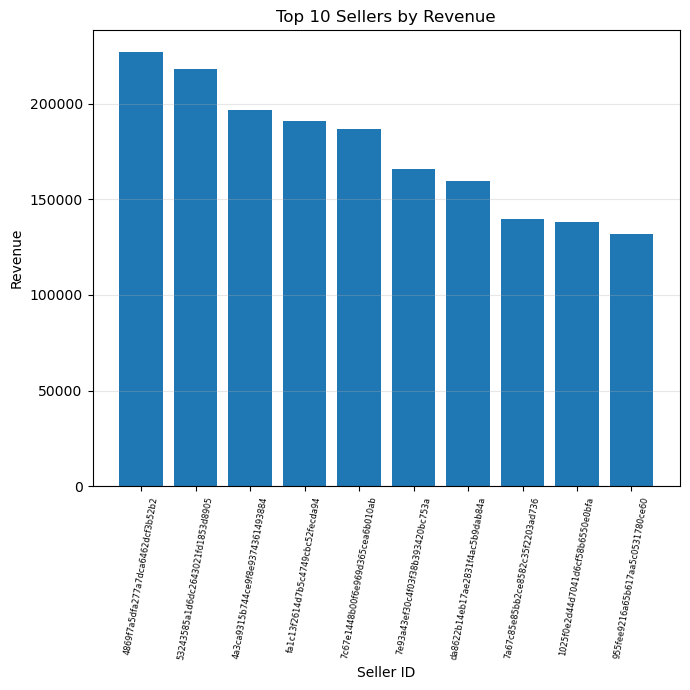

In [43]:
plt.figure(figsize=(7, 7))

plt.bar(
    top_sellers["seller_id"],
    top_sellers["total_revenue"]
)

plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Seller ID")
plt.ylabel("Revenue")
plt.xticks(rotation=80, fontsize=6)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Business Interpretation

The analysis identifies the marketplace's highest-revenue sellers based on completed orders.

The results show that a relatively small group of sellers generates a significant share of total revenue. These sellers represent key business partners whose performance has a substantial impact on the marketplace.

From a business perspective, monitoring top sellers helps prioritize partnership programs, improve seller retention, and identify opportunities to increase overall marketplace revenue.